In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Coffee Shop Sales.xlsx to Coffee Shop Sales.xlsx


In [ ]:
df = pd.read_excel("Coffee Shop Sales.xlsx")

In [ ]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:
df.shape

(149116, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [ ]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [ ]:
df.isnull().sum()

,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["revenue"] = df["transaction_qty"] * df["unit_price"]

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [ ]:
df["revenue"].sum()

np.float64(698812.3300000002)

In [ ]:
df["transaction_id"].nunique()

149116

In [ ]:
df["transaction_qty"].sum()

np.int64(214470)

In [ ]:
df["transaction_qty"].sum()

np.int64(214470)

Business Question 1

Produk apa yang menghasilkan revenue terbesar?

In [ ]:
top_product = (
    df.groupby("product_detail")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_product.head(10)

,revenue
product_detail,
Sustainably Grown Organic Lg,21151.75
Dark chocolate Lg,21006.00
Latte Rg,19112.25
Cappuccino Lg,17641.75
Morning Sunrise Chai Lg,17384.00
Latte,17257.50
Jamaican Coffee River Lg,16481.25
Sustainably Grown Organic Rg,16233.75
Cappuccino,15997.50


Business Question 2

Kategori mana yang paling banyak menghasilkan uang?

In [ ]:
top_category = (
    df.groupby("product_category")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_category

,revenue
product_category,
Coffee,269952.45
Tea,196405.95
Bakery,82315.64
Drinking Chocolate,72416.00
Coffee beans,40085.25
Branded,13607.00
Loose Tea,11213.60
Flavours,8408.80
Packaged Chocolate,4407.64


Business Question 4

Jam berapa paling ramai?

In [ ]:
df["hour"] = pd.to_datetime(df["transaction_time"], format="%H:%M:%S").dt.hour

In [ ]:
sales_hour = (
    df.groupby("hour")["transaction_id"]
      .count()
)

sales_hour

,transaction_id
hour,
6,4594
7,13428
8,17654
9,17764
10,18545
11,9766
12,8708
13,8714
14,8933


# Exploratory Data Analysis (EDA)

Business Question 1
Bagaimana tren penjualan dari waktu ke waktu?

In [ ]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

daily_sales = (
    df.groupby("transaction_date")["revenue"]
      .sum()
      .reset_index()
)

daily_sales.head()

,transaction_date,revenue
0,2023-01-01,2508.20
1,2023-01-02,2403.35
2,2023-01-03,2565.00
3,2023-01-04,2220.10
4,2023-01-05,2418.85


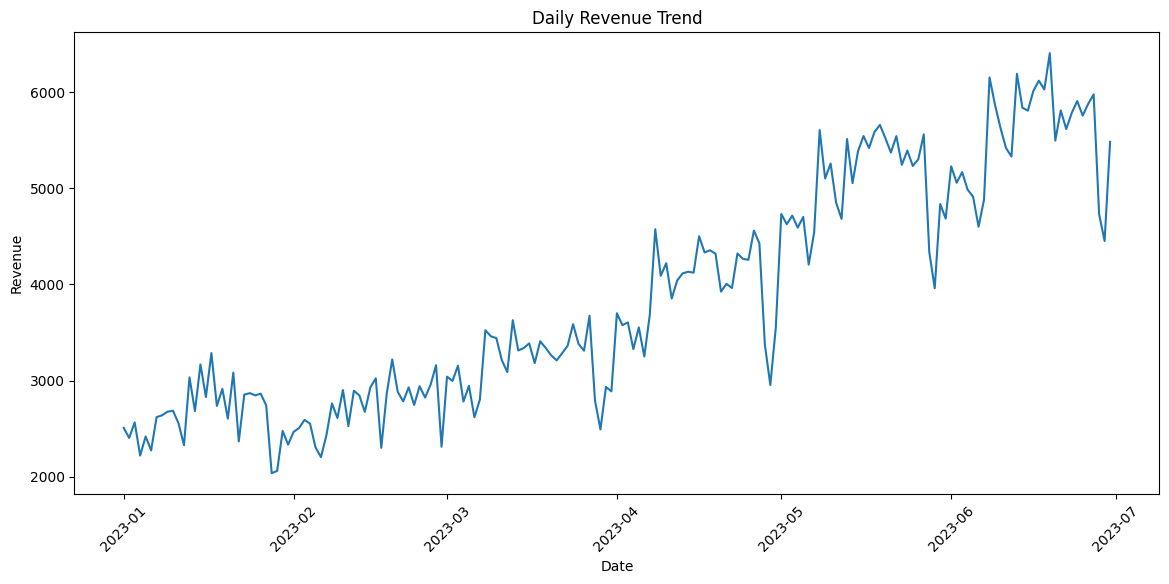

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    daily_sales["transaction_date"],
    daily_sales["revenue"]
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

##Insight

Tidak ada perbedaan yang sangat besar antarhari, namun awal dan akhir minggu kerja menunjukkan performa sedikit lebih tinggi.

##Recommendation

Lakukan promosi khusus pada hari dengan penjualan lebih rendah (misalnya akhir pekan jika targetnya meningkatkan traffic).
Evaluasi efektivitas promosi berdasarkan data setelah implementasi.

Business Question 2
Revenue berdasarkan Cabang

In [ ]:
store_sales = (
    df.groupby("store_location")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

store_sales

,revenue
store_location,
Hell's Kitchen,236511.17
Astoria,232243.91
Lower Manhattan,230057.25


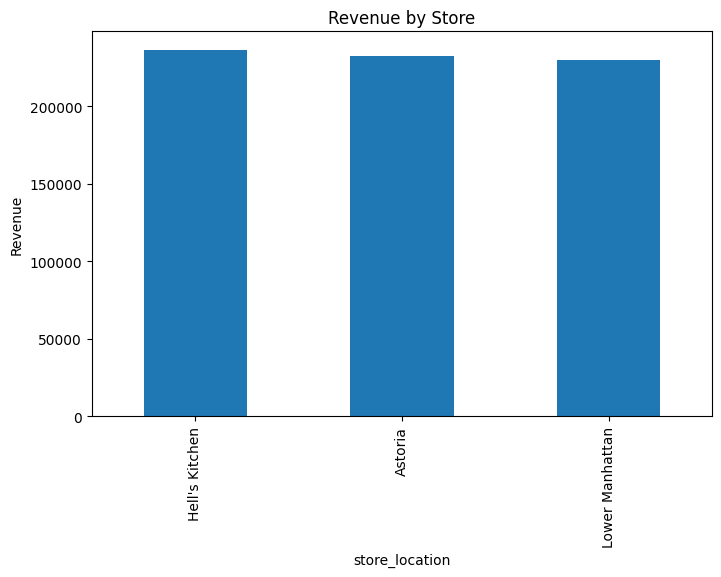

In [ ]:
store_sales.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Store")
plt.ylabel("Revenue")

plt.show()

##Insight

Hell's Kitchen merupakan cabang dengan revenue tertinggi.
Ketiga cabang memiliki performa yang cukup berdekatan, namun Hell's Kitchen tetap menjadi kontributor terbesar.

##Recommendation

Pelajari strategi operasional Hell's Kitchen (produk terlaris, jam sibuk, pola pembelian).
Terapkan strategi yang berhasil ke cabang lain untuk meningkatkan performa secara keseluruhan.

Business Question 3
Top 10 Produk

In [ ]:
top10 = (
    df.groupby("product_detail")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top10

,revenue
product_detail,
Sustainably Grown Organic Lg,21151.75
Dark chocolate Lg,21006.00
Latte Rg,19112.25
Cappuccino Lg,17641.75
Morning Sunrise Chai Lg,17384.00
Latte,17257.50
Jamaican Coffee River Lg,16481.25
Sustainably Grown Organic Rg,16233.75
Cappuccino,15997.50


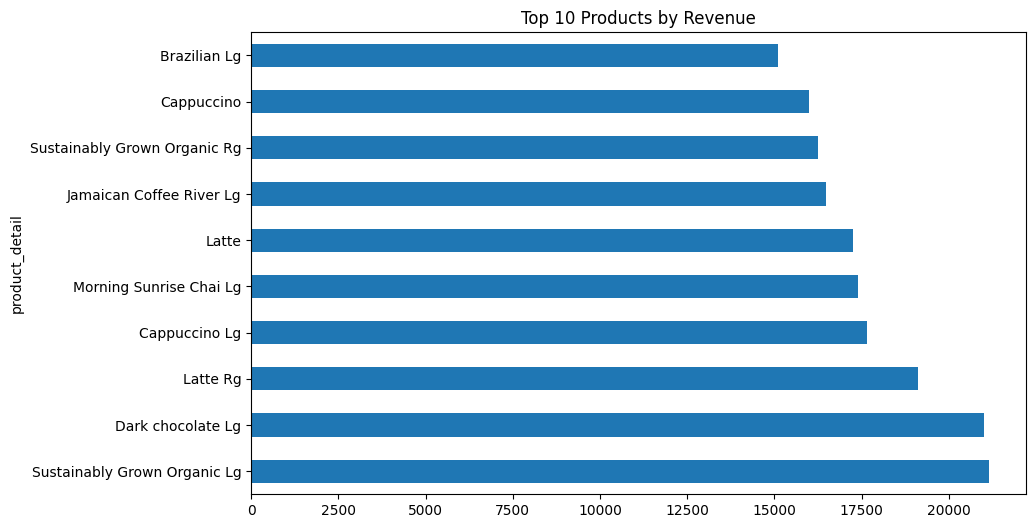

In [ ]:
top10.plot(kind="barh", figsize=(10,6))

plt.title("Top 10 Products by Revenue")

plt.show()

##Insight

Produk-produk di atas menghasilkan revenue tertinggi sehingga memiliki permintaan yang kuat.

##Recommendation

Jadikan produk tersebut sebagai featured menu.
Gunakan dalam promo musiman atau paket bundling.
Pastikan ketersediaan bahan baku tetap terjaga.

Business Question 4
Revenue berdasarkan Kategori

In [ ]:
category = (
    df.groupby("product_category")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

category

,revenue
product_category,
Coffee,269952.45
Tea,196405.95
Bakery,82315.64
Drinking Chocolate,72416.00
Coffee beans,40085.25
Branded,13607.00
Loose Tea,11213.60
Flavours,8408.80
Packaged Chocolate,4407.64


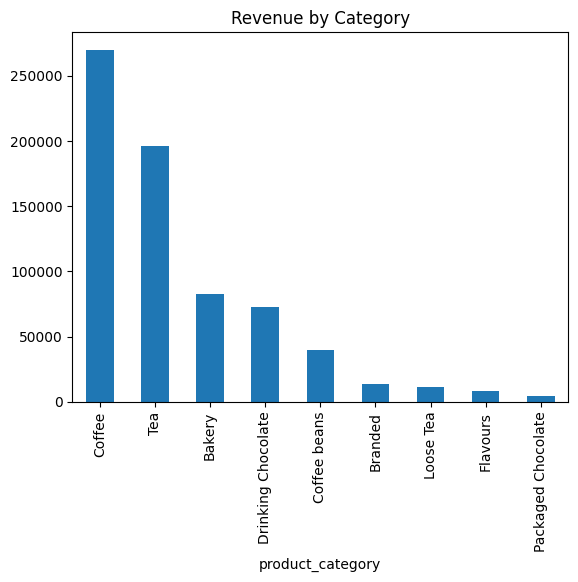

In [ ]:
category.plot(kind="bar")

plt.title("Revenue by Category")

plt.show()

##Insight

Coffee memberikan kontribusi revenue terbesar.
Tea berada di posisi kedua dengan selisih yang cukup besar.
Bakery dan Drinking Chocolate menjadi kategori pendukung.

##Recommendation

Fokus promosi pada kategori Coffee sebagai produk utama.
Buat bundling Coffee + Bakery untuk meningkatkan nilai transaksi.

Business Question 5
Peak Hour

In [ ]:
hourly = (
    df.groupby("hour")["transaction_id"]
      .count()
)

hourly

,transaction_id
hour,
6,4594
7,13428
8,17654
9,17764
10,18545
11,9766
12,8708
13,8714
14,8933


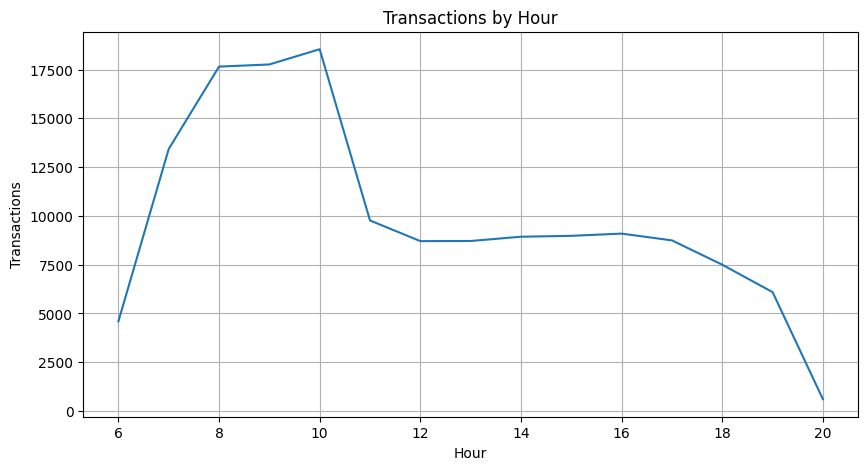

In [ ]:
hourly.plot(figsize=(10,5))

plt.title("Transactions by Hour")

plt.xlabel("Hour")
plt.ylabel("Transactions")

plt.grid()

plt.show()

##Insight

Puncak penjualan terjadi pada 08.00–10.00, terutama sekitar pukul 10.00.

Hal ini menunjukkan mayoritas pelanggan datang pada pagi hari.

##Recommendation

Tambah staf pada jam 08.00–10.00.
Pastikan stok produk populer tersedia sebelum jam sibuk.
Jalankan promo breakfast pada rentang waktu tersebut

Business Question 6
Hari apa yang paling ramai?

In [ ]:
df["day_name"] = df["transaction_date"].dt.day_name()

In [ ]:
weekday = (
    df.groupby("day_name")["revenue"]
      .sum()
)

weekday

,revenue
day_name,
Friday,101373.00
Monday,101677.28
Saturday,96894.48
Sunday,98330.31
Thursday,100767.78
Tuesday,99455.94
Wednesday,100313.54


In [ ]:
order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday = weekday.reindex(order)

weekday

,revenue
day_name,
Monday,101677.28
Tuesday,99455.94
Wednesday,100313.54
Thursday,100767.78
Friday,101373.00
Saturday,96894.48
Sunday,98330.31


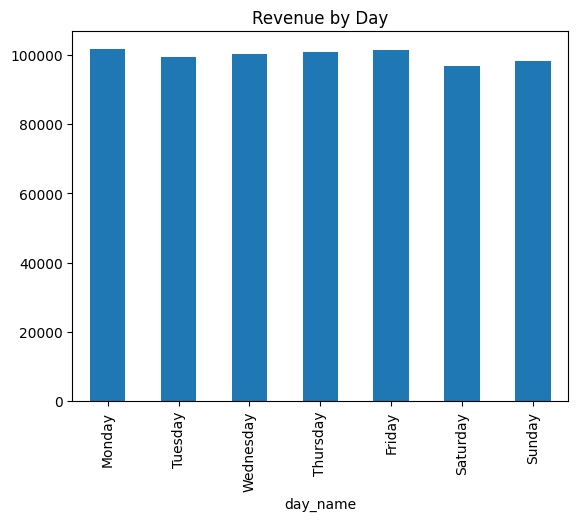

In [ ]:
weekday.plot(kind="bar")

plt.title("Revenue by Day")

plt.show()

##Insight

Berdasarkan hasil analisis, penjualan tertinggi terjadi pada **Monday (Senin)**.
Hal ini menunjukkan bahwa awal minggu menjadi periode dengan aktivitas pembelian paling tinggi dibandingkan hari lainnya.
Perbedaan revenue antar hari relatif tidak terlalu besar, sehingga pola penjualan selama satu minggu cenderung stabil.

## Recommendation

Siapkan stok dan tenaga kerja yang cukup pada hari Senin untuk mengantisipasi tingginya permintaan.
Lakukan promosi pada hari dengan penjualan lebih rendah untuk membantu meningkatkan traffic dan menjaga kestabilan penjualan sepanjang minggu.

Business Question 7
Produk Terlaris (berdasarkan jumlah item)

In [ ]:
best_seller = (
    df.groupby("product_detail")["transaction_qty"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

best_seller

,transaction_qty
product_detail,
Earl Grey Rg,4708
Dark chocolate Lg,4668
Morning Sunrise Chai Rg,4643
Latte,4602
Peppermint Rg,4564
Columbian Medium Roast Rg,4547
Traditional Blend Chai Rg,4512
Latte Rg,4497
Our Old Time Diner Blend Sm,4484


## Insight

Produk dengan jumlah item terjual tertinggi menunjukkan preferensi pelanggan terhadap menu tertentu.
Produk-produk tersebut memiliki permintaan yang konsisten dan menjadi kontributor utama terhadap volume penjualan coffee shop.
Tingginya jumlah item yang terjual belum tentu menghasilkan revenue terbesar, sehingga analisis quantity dan revenue perlu dipertimbangkan secara bersamaan.

## Recommendation

Pastikan ketersediaan stok untuk produk dengan jumlah penjualan tertinggi agar tidak terjadi kehabisan stok.
Jadikan produk terlaris sebagai menu unggulan dalam strategi promosi dan bundling untuk meningkatkan nilai transaksi pelanggan.